# High Dynamic Range (HDR) Imaging



In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
%matplotlib inline

##  <font style="color:black">Download Assets</font>

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/qa1hsyxt66pvj02/opencv_bootcamp_assets_NB10.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB10.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Capture Multiple Exposures

In [4]:
def readImagesAndTimes():
    filenames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]
    times = np.array([1 / 30.0, 0.25, 2.5, 15.0], dtype=np.float32)
    # Read
    images = []
    for filename in filenames:
        im = cv2.imread(filename)
        images.append(im)
    return images, times

# Align Images

In [5]:
# read images and exposure times
images, times = readImagesAndTimes()
# align
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)

# Estimate Camera Response Function

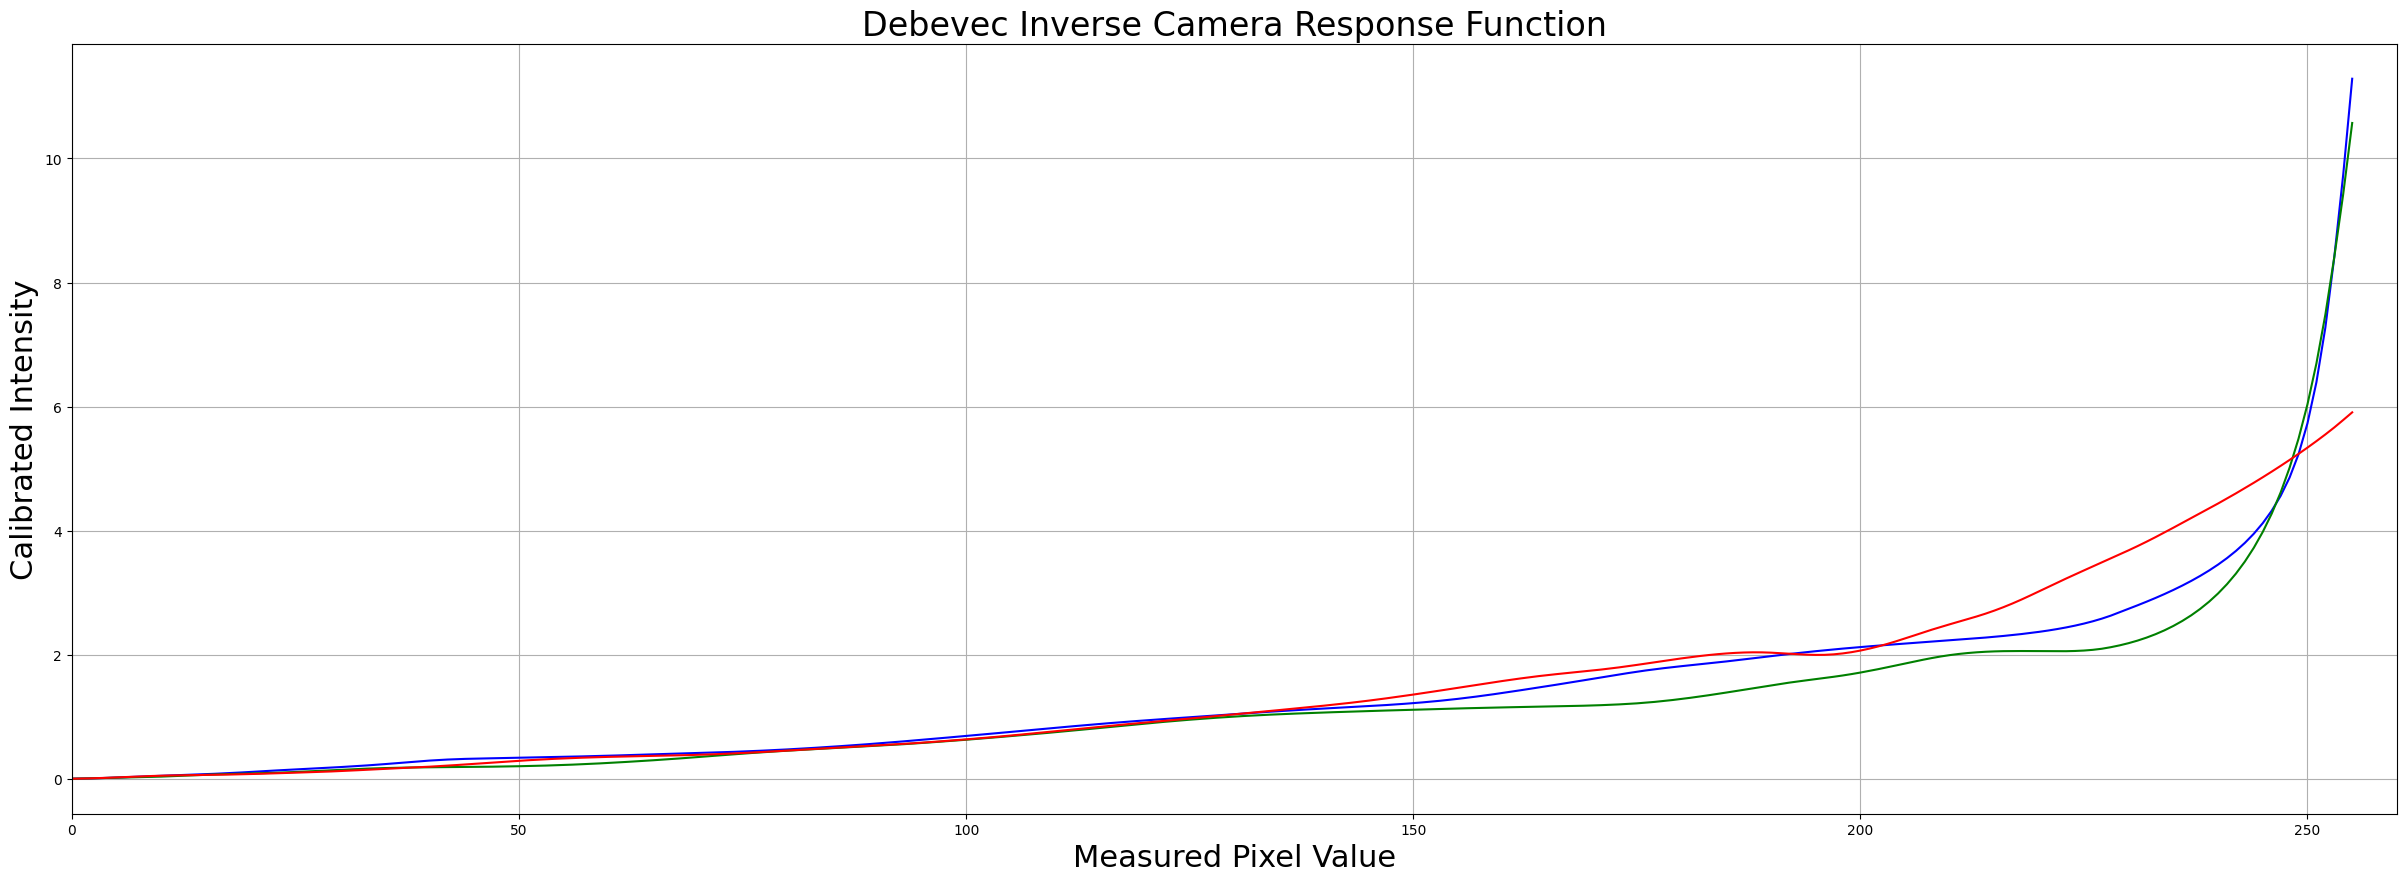

In [6]:
# CRF
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)
# Plot
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=(30, 10))
plt.title("Debevec Inverse Camera Response Function", fontsize=24)
plt.xlabel("Measured Pixel Value", fontsize=22)
plt.ylabel("Calibrated Intensity", fontsize=22)
plt.xlim([0, 260])
plt.grid()
plt.plot(x, y[:, 0], "b", x, y[:, 1], "g", x, y[:, 2], "r")

# Merge Exposure into an HDR Image

In [7]:
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

# Tonemapping

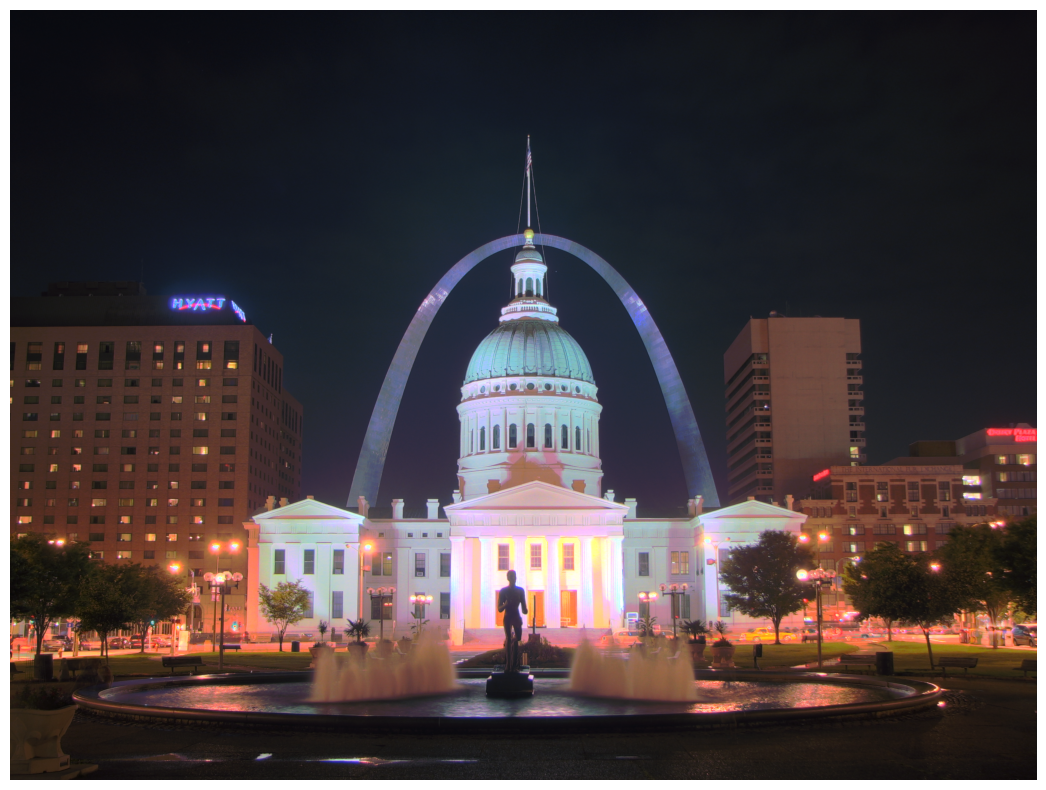

In [8]:
# drago's method
tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago
# saving
cv2.imwrite("ldr-Drago.jpg", 255*ldrDrago)
# plot
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrDrago, 0, 1)[:,:,::-1]);plt.axis("off");

(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

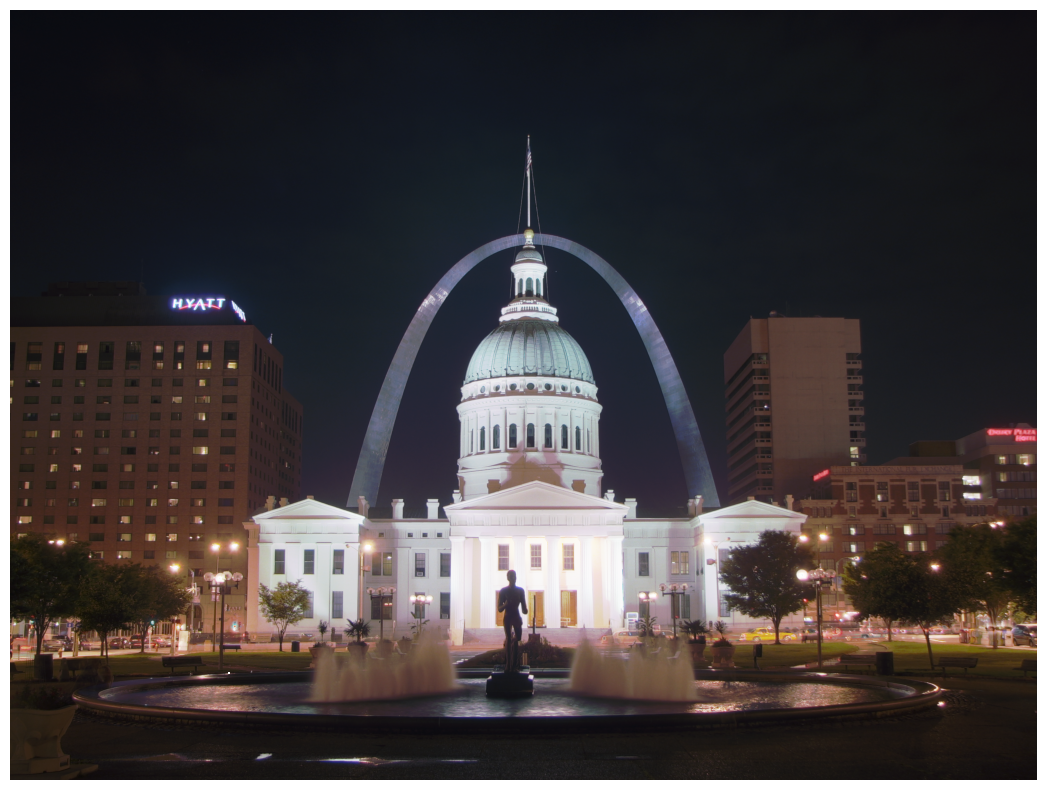

In [9]:
# reinhard's method
tonemapReinhard = cv2.createTonemapReinhard(1.5, 0, 0, 0)
ldrReinhard = tonemapReinhard.process(hdrDebevec)
# saving
cv2.imwrite("ldr-Reinhard.jpg", ldrReinhard * 255)
# plot
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrReinhard, 0, 1)[:,:,::-1]);plt.axis("off")

(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

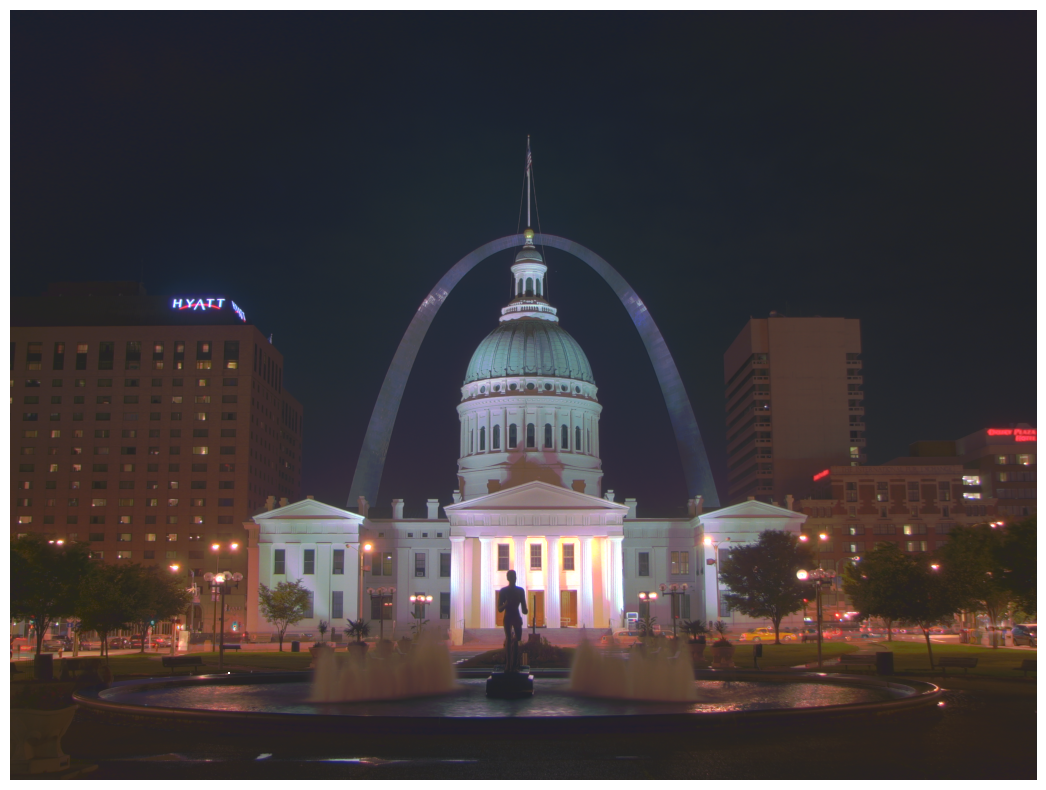

In [10]:
# mantiuk's method
tonemapMantiuk = cv2.createTonemapMantiuk(2.2, 0.85, 1.2)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = 3 * ldrMantiuk
# save
cv2.imwrite("ldr-Mantiuk.jpg", ldrMantiuk * 255)
#plot
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrMantiuk, 0, 1)[:,:,::-1]);plt.axis("off")